<a href="https://colab.research.google.com/github/MusicalManiac/Coastal-Change-Detection-Using-SAR-U-Net/blob/main/notebooks/idai_reference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import urllib.request

REF_DIR = Path('/content/drive/MyDrive/geog761_project/data/idai/reference')
REF_DIR.mkdir(parents=True, exist_ok=True)

# Source: Copernicus EMS activation EMSR348 (Cyclone Idai, Mozambique)
# https://mapping.emergency.copernicus.eu/activations/EMSR348/
BASE = 'https://cems-mapping-website.s3.eu-west-1.amazonaws.com/static/activations/EMSR348/'
products = [
    'EMSR348_03BEIRA_01DELINEATION_MAP_v1',      # flood extent, ~16 Mar (main reference)
    'EMSR348_03BEIRA_01DELINEATION_MONIT01_v2',  # flood extent update, Apr
    'EMSR348_03BEIRA_01DELINEATION_MONIT02_v2',  # flood extent update, Apr
    'EMSR348_16BEIRANORTH_02GRADING_MAP_v2',     # damage grading (no delineation exists)
]

for p in products:
    for suffix in ['_vector.zip', '_200dpi.pdf']:   # data + map PDF (for the image date)
        out = REF_DIR / (p + suffix)
        if not out.exists():
            urllib.request.urlretrieve(BASE + p + suffix, out)
        print('saved', out.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
saved EMSR348_03BEIRA_01DELINEATION_MAP_v1_vector.zip
saved EMSR348_03BEIRA_01DELINEATION_MAP_v1_200dpi.pdf
saved EMSR348_03BEIRA_01DELINEATION_MONIT01_v2_vector.zip
saved EMSR348_03BEIRA_01DELINEATION_MONIT01_v2_200dpi.pdf
saved EMSR348_03BEIRA_01DELINEATION_MONIT02_v2_vector.zip
saved EMSR348_03BEIRA_01DELINEATION_MONIT02_v2_200dpi.pdf
saved EMSR348_16BEIRANORTH_02GRADING_MAP_v2_vector.zip
saved EMSR348_16BEIRANORTH_02GRADING_MAP_v2_200dpi.pdf


In [4]:
import zipfile

WORK = Path('/content/reference')   # fast temporary space; rebuilt each session from Drive
WORK.mkdir(exist_ok=True)

for z in sorted(REF_DIR.glob('*_vector.zip')):
    dest = WORK / z.stem.replace('_vector', '')
    with zipfile.ZipFile(z) as zf:
        zf.extractall(dest)
    print('unzipped', dest.name)

unzipped EMSR348_03BEIRA_01DELINEATION_MAP_v1
unzipped EMSR348_03BEIRA_01DELINEATION_MONIT01_v2
unzipped EMSR348_03BEIRA_01DELINEATION_MONIT02_v2
unzipped EMSR348_16BEIRANORTH_02GRADING_MAP_v2


In [5]:
for product in sorted(WORK.iterdir()):
    print('\n==', product.name)
    for shp in sorted(product.rglob('*.shp')):
        print('   ', shp.name)


== EMSR348_03BEIRA_01DELINEATION_MAP_v1
    EMSR348_03BEIRA_DEL_v1_area_of_interest_a.shp
    EMSR348_03BEIRA_DEL_v1_built_up_a.shp
    EMSR348_03BEIRA_DEL_v1_facilities_p.shp
    EMSR348_03BEIRA_DEL_v1_hydrography_a.shp
    EMSR348_03BEIRA_DEL_v1_hydrography_l.shp
    EMSR348_03BEIRA_DEL_v1_image_footprint_a.shp
    EMSR348_03BEIRA_DEL_v1_natural_land_use_a.shp
    EMSR348_03BEIRA_DEL_v1_observed_event_a.shp
    EMSR348_03BEIRA_DEL_v1_physiography_l.shp
    EMSR348_03BEIRA_DEL_v1_transportation_l.shp
    EMSR348_03BEIRA_DEL_v1_transportation_p.shp

== EMSR348_03BEIRA_01DELINEATION_MONIT01_v2
    EMSR348_03BEIRA_DEL_MONIT01_v2_area_of_interest_a.shp
    EMSR348_03BEIRA_DEL_MONIT01_v2_built_up_a.shp
    EMSR348_03BEIRA_DEL_MONIT01_v2_facilities_p.shp
    EMSR348_03BEIRA_DEL_MONIT01_v2_hydrography_a.shp
    EMSR348_03BEIRA_DEL_MONIT01_v2_hydrography_l.shp
    EMSR348_03BEIRA_DEL_MONIT01_v2_image_footprint_a.shp
    EMSR348_03BEIRA_DEL_MONIT01_v2_natural_land_use_a.shp
    EMSR348_03BEIR

In [6]:
import geopandas as gpd

def find_layer(folder, *keywords):
    """Return the first shapefile whose name contains any keyword (case-insensitive)."""
    for shp in sorted(folder.rglob('*.shp')):
        name = shp.name.lower().replace('_', '')
        if any(k in name for k in keywords):
            return shp
    raise FileNotFoundError(f'No layer matching {keywords} in {folder.name}')

main = WORK / 'EMSR348_03BEIRA_01DELINEATION_MAP_v1'

flood = gpd.read_file(find_layer(main, 'observedevent'))        # flood extent
water = gpd.read_file(find_layer(main, 'hydrography'))          # permanent rivers/lakes/sea
aoi   = gpd.read_file(find_layer(main, 'areaofinterest', 'aoi'))  # the mapped area boundary

for name, gdf in [('flood', flood), ('water', water), ('aoi', aoi)]:
    print(f'{name}: {len(gdf)} features, CRS = {gdf.crs}')

flood.head()   # look at the attribute table

flood: 1 features, CRS = EPSG:4326
water: 14 features, CRS = EPSG:4326
aoi: 1 features, CRS = EPSG:4326


,event_type,obj_desc,det_method,notation,dmg_src_id,geometry
0,5-Flood,Coastal flood,Semi-automatic extraction,Flooded area,2,"MULTIPOLYGON (((34.85402 -19.84803, 34.85402 -..."


Text(0.5, 1.0, 'EMSR348 AOI03 Beira (first delineation): flood (red), permanent water (blue)')

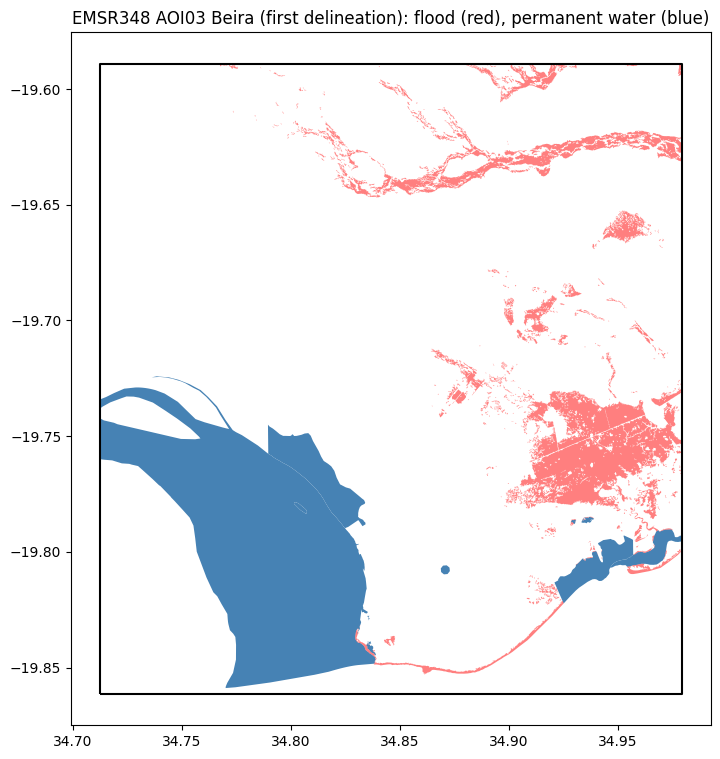

In [7]:
ax = aoi.boundary.plot(color='black', figsize=(9, 9))
water.plot(ax=ax, color='steelblue')
flood.plot(ax=ax, color='red', alpha=0.5)
ax.set_title('EMSR348 AOI03 Beira (first delineation): flood (red), permanent water (blue)')